In [1]:
'''
Title: Titanic Exploratory Data Analysis
Name: Sandra Lung'ahi
Cyber Shujaa ID: CS-DA02-25069
Date: 3rd October, 2025
Description: Initial Data Exploration, Handling Missing Values and Outliers, Univariate Analysis, Bivariate Analysis, Multivariate Analysis,Target Variable Analysis.
'''

"\nTitle: Titanic Exploratory Data Analysis\nName: Sandra Lung'ahi\nCyber Shujaa ID: CS-DA02-25069\nDescription: Initial Data Exploration, Handling Missing Values and Outliers, Univariate Analysis, Bivariate Analysis, Multivariate Analysis,Target Variable Analysis.\n"

In [2]:
# Importing libraries
import pandas as pd  
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno 
import seaborn as sns
sns.set_theme(style='darkgrid', context='notebook')
import warnings as wr
wr.filterwarnings('ignore')

In [4]:
#Load Dataset
df = pd.read_csv("/kaggle/input/titanic/train.csv")

 **1. Initial Data Exploration**

In [18]:
# Preview the dataset
df.head() # First five rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# Number of rows and columns
df.shape 

(891, 12)

In [20]:
# Overview of the dataset's columns, their datatypes and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [30]:
print("Summary for numerical columns:\n", df.describe()) #summary statistics
print("Column Names:\n", df.columns.tolist()) # Lists names of columns
print("Unique values:\n", df.nunique()) # Number of unique values
print("Duplicates:\n", df.duplicated().sum()) # number of duplicate rows

Summary for numerical columns:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
Column Names:
 ['PassengerId', 'Survived', 'Pclas

**2. Univariate Analysis**

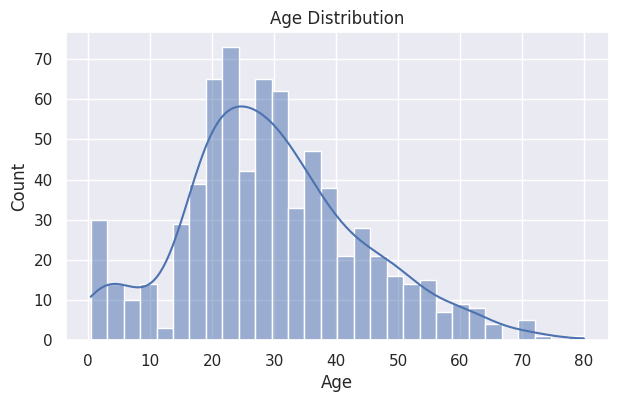

In [39]:
# Histogram to check Age distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

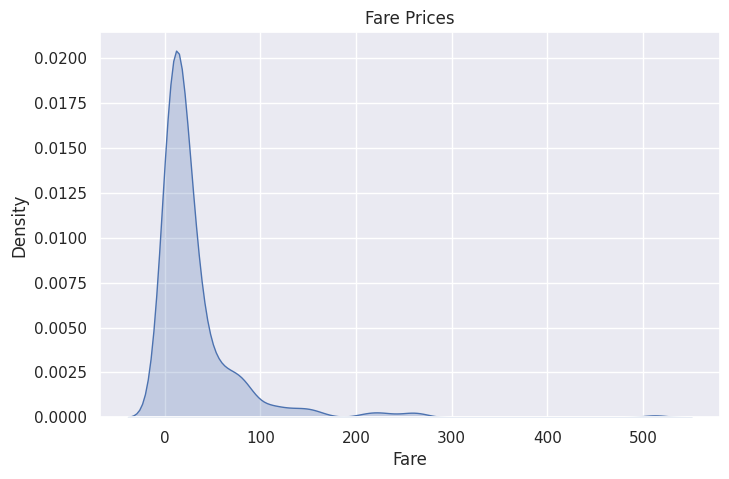

In [40]:
# KDE Plot for Prices
plt.figure(figsize=(8, 5))
sns.kdeplot(df['Fare'], shade=True)
plt.title('Fare Prices')
plt.xlabel('Fare')
plt.show()

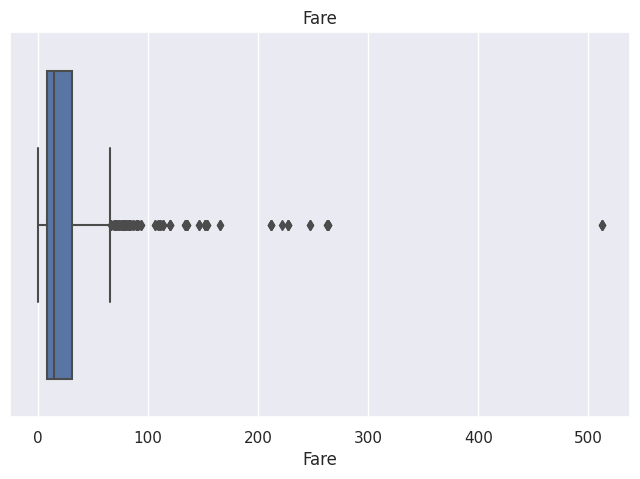

In [42]:
# Boxplot for detecting outliers in Fare prices
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'])
plt.title('Fare')
plt.show()

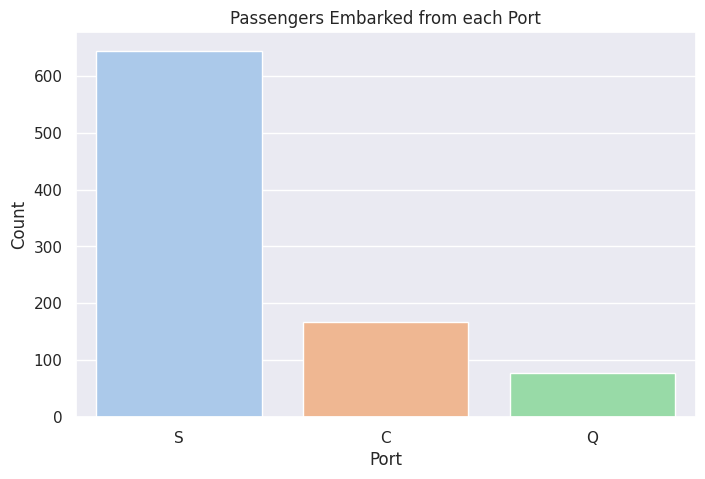

In [43]:
# Countplot for Passengers Embarked
plt.figure(figsize=(8, 5))
sns.countplot(x='Embarked', data=df, palette='pastel')
plt.title('Passengers Embarked from each Port')
plt.xlabel('Port')
plt.ylabel('Count')
plt.show()

**3. Bivariate Analysis**

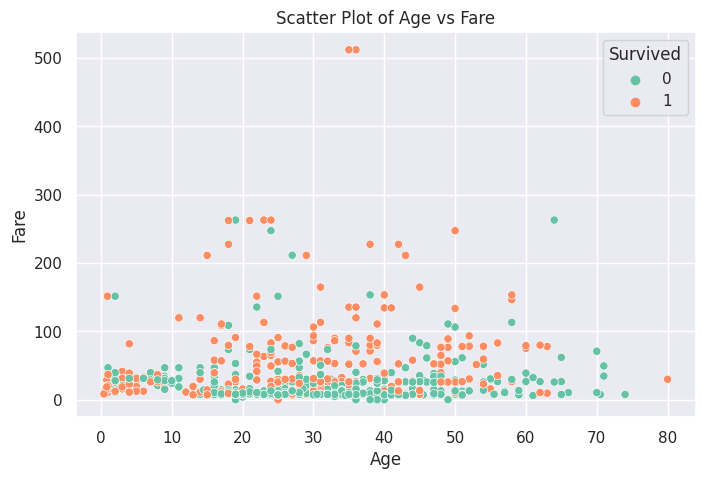

In [48]:
# Numerical VS numerical analysis
# Scatter plot for Age vs Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Fare', data=df, hue='Survived', palette='Set2')
plt.title('Scatter Plot of Age vs Fare')
plt.show()

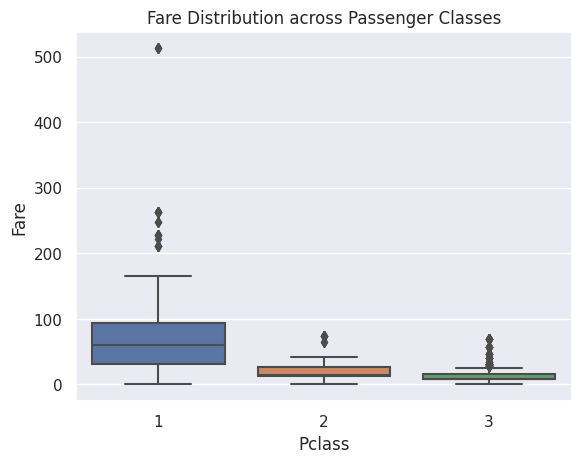

In [49]:
# Numerical VS Categorical
# Changes in fare depending on PClass
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare Distribution across Passenger Classes')
plt.show()



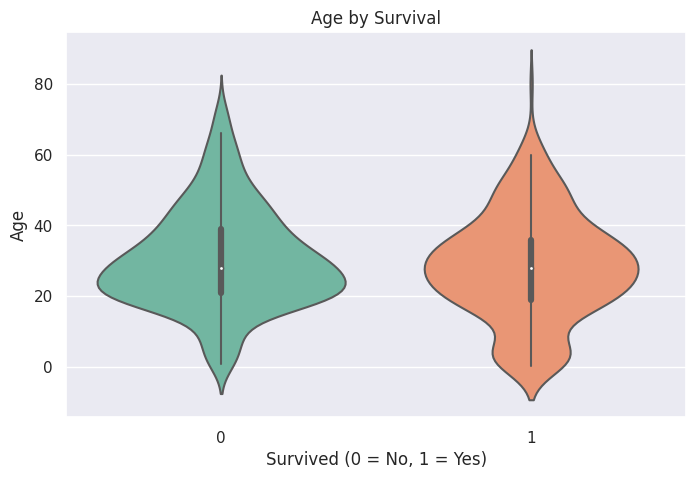

In [51]:
# Violin plot of Age grouped by Survived
plt.figure(figsize=(8, 5))
sns.violinplot(x='Survived', y='Age', data=df, split=True, palette='Set2')
plt.title('Age by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

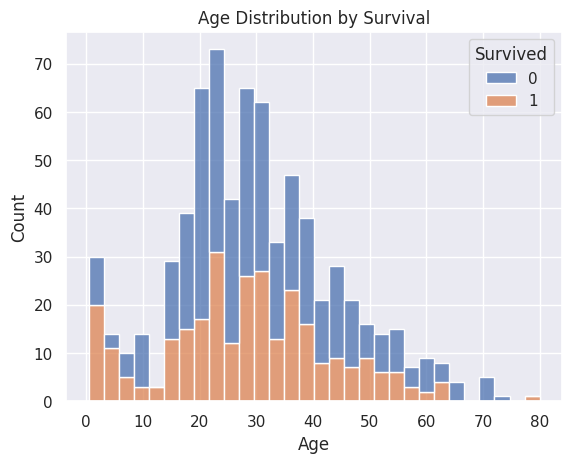

In [60]:
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show()


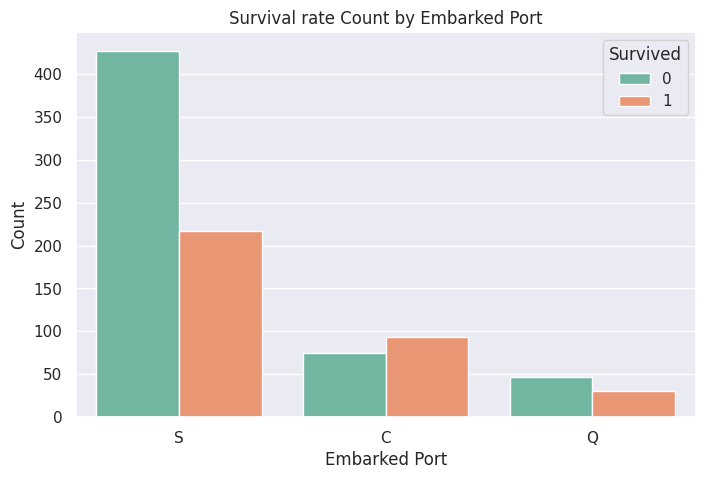

In [6]:
# Categorical VS Categorical analysis
# Grouped Bar plot of Survived vs Embarked
plt.figure(figsize=(8, 5))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='Set2')
plt.title('Survival rate Count by Embarked Port')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.show()

**4. Multivariate Analysis**

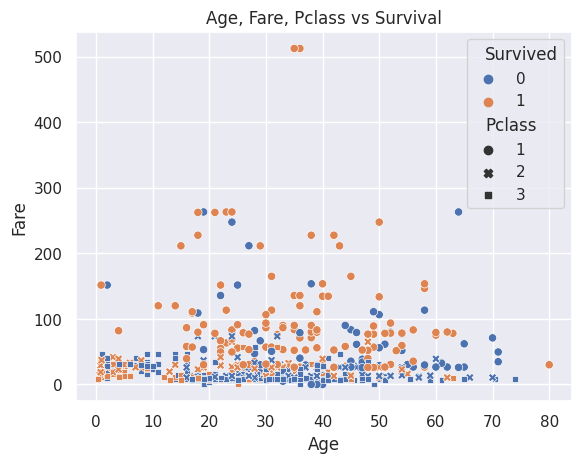

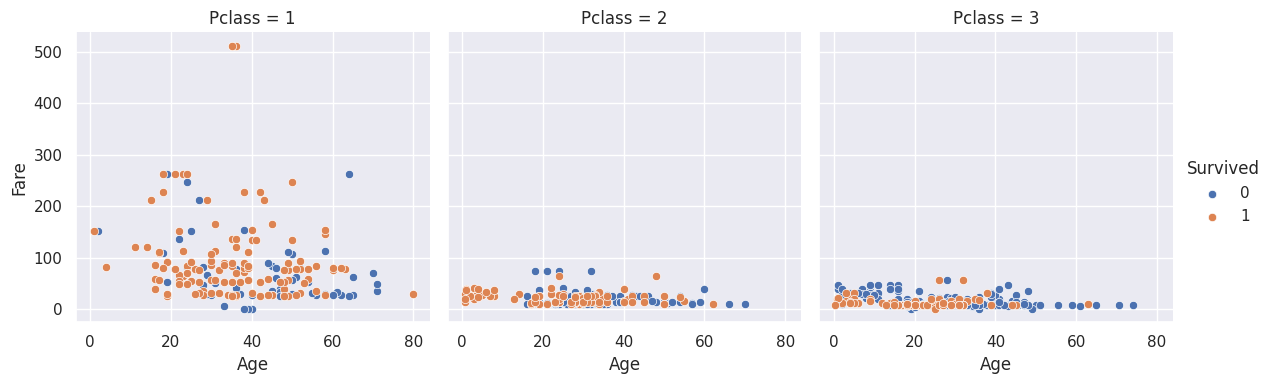

In [8]:
# # 3D scatter plot for Age, Fare, and Survived
sns.scatterplot(x="Age", y="Fare", hue="Survived", style="Pclass", data=df)
plt.title("Age, Fare, Pclass vs Survival")
plt.show()
# FacetGrid for Age distribution by Survived and Pclass
g = sns.FacetGrid(df, col="Pclass", hue="Survived", height=4)
g.map_dataframe(sns.scatterplot, x="Age", y="Fare")
g.add_legend()


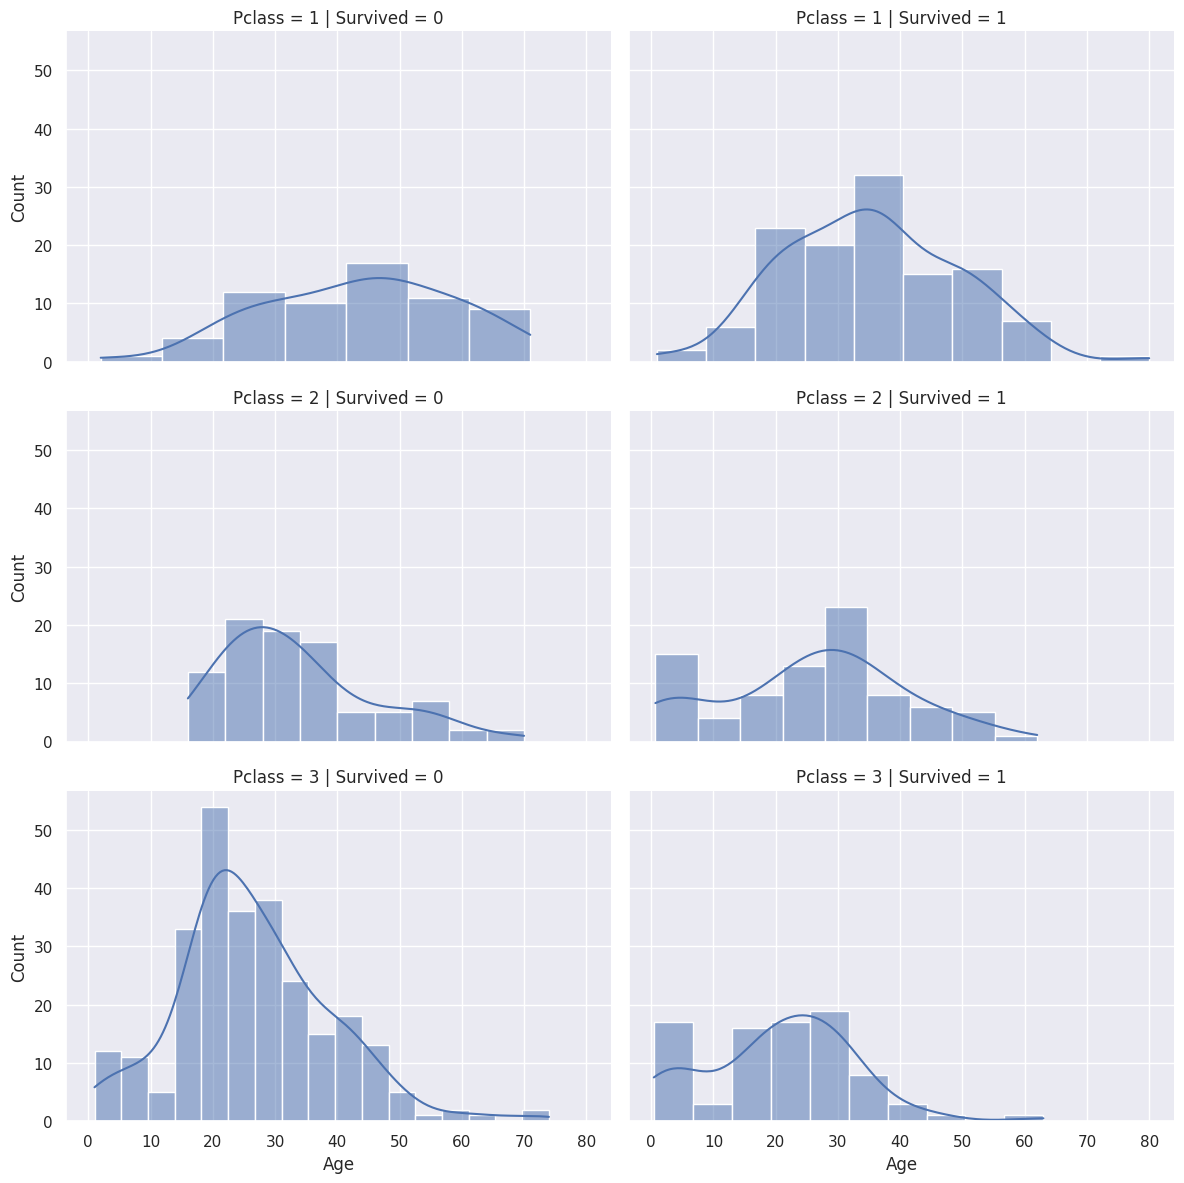

In [10]:
# FacetGrid for Age distribution by Survived and Pclass
g = sns.FacetGrid(df, col='Survived', row='Pclass', height=4, aspect=1.5)
g.map(sns.histplot, 'Age', kde=True)
plt.show()

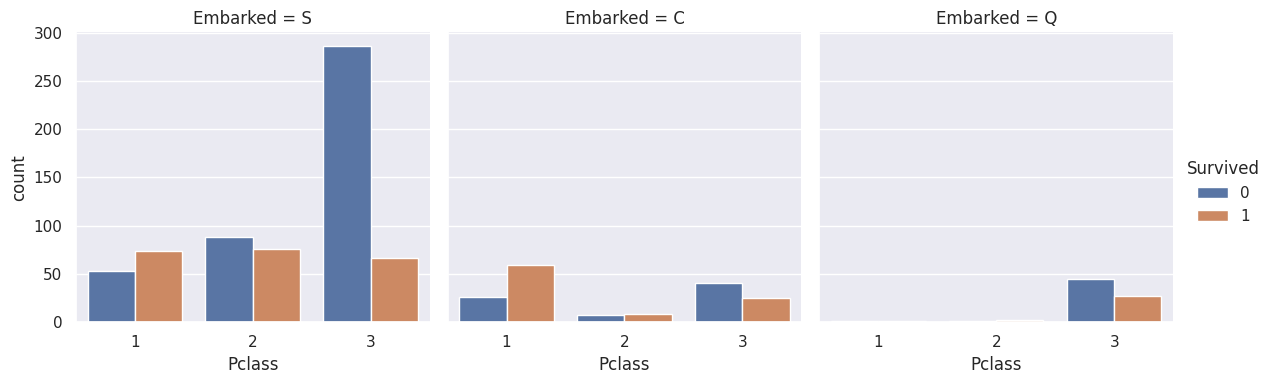

In [11]:
# Grouped bar plot
sns.catplot(x="Pclass", hue="Survived", col="Embarked",
            kind="count", data=df, height=4)
plt.show()


**5. Outlier Detection and Handling**

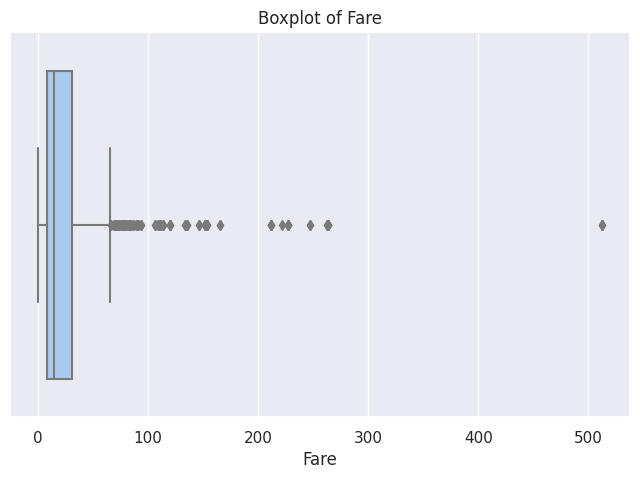

In [20]:
# Boxplot for Fare to detect outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'], palette='pastel')
plt.title('Boxplot of Fare')
plt.show()

In [15]:
# Function to detect outliers using Z-score
from scipy.stats import zscore

def detect_outliers_zscore(data, threshold=3):
    # Drop NaNs, calculate z-scores only for valid values
    z_scores = pd.Series(zscore(data.dropna()), index=data.dropna().index)
    # Mark outliers
    outliers = data.loc[z_scores[abs(z_scores) > threshold].index]
    return outliers

# Detect outliers in the 'Age' column
outliers_age = detect_outliers_zscore(df['Age'])
print(f'Number of outliers in Age: {len(outliers_age)}')


Number of outliers in Age: 2


In [16]:
# Function to detect outliers using IQR
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

# Detect outliers in the 'Fare' column using IQR
outliers_fare = detect_outliers_iqr(df['Fare'])
print(f'Number of outliers in Fare: {len(outliers_fare)}')

Number of outliers in Fare: 116


**6. Target Variable Exploration**

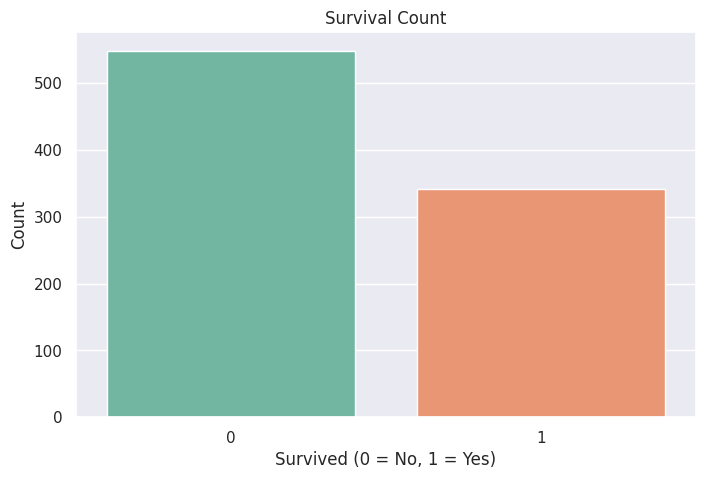

In [19]:
# Countplot for Survived
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

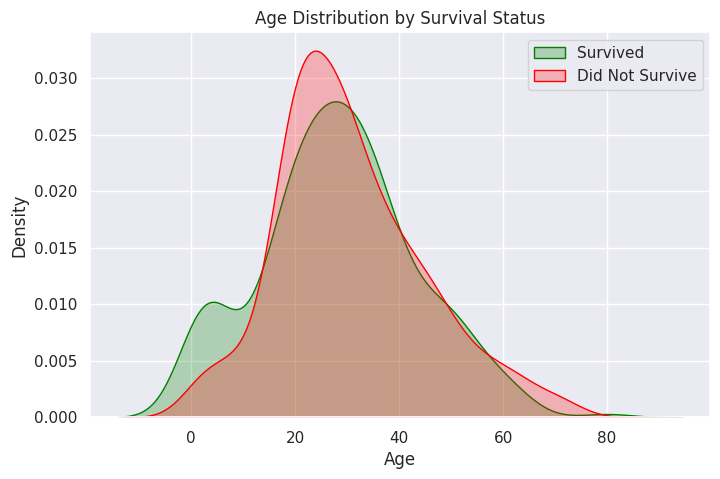

In [21]:
# KDE Plot for Age by Survival Status
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['Survived'] == 1]['Age'], shade=True, label='Survived', color='green')
sns.kdeplot(df[df['Survived'] == 0]['Age'], shade=True, label='Did Not Survive', color='red')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.legend()
plt.show()

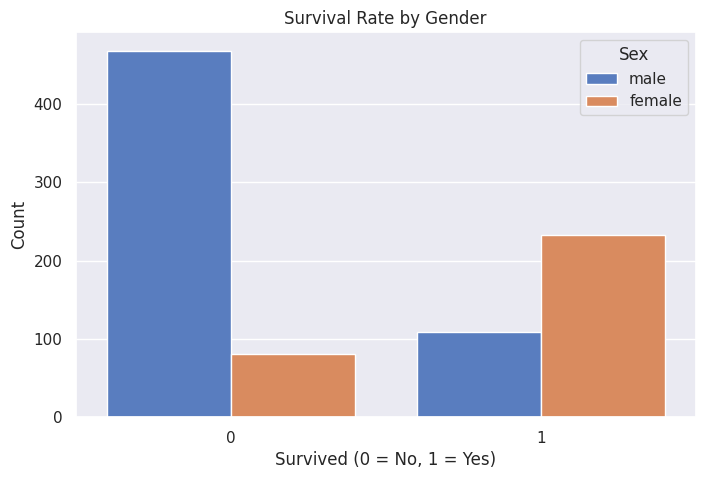

In [22]:
# Countplot for Survived grouped by Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=df, palette='muted')
plt.title('Survival Rate by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [23]:
# Calculate survival rate by gender
gender_survival_rate = df.groupby('Sex')['Survived'].apply(lambda x: (x == 1).mean() * 100)
print(gender_survival_rate)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


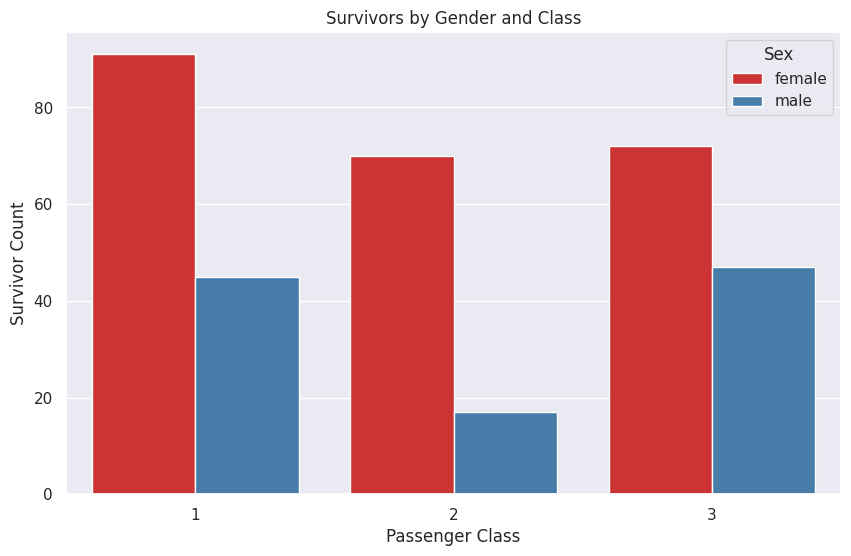

In [24]:
# Grouped bar plot for survival by Gender and Class
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Sex', data=df[df['Survived'] == 1], palette='Set1')
plt.title('Survivors by Gender and Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survivor Count')
plt.show()